## 0.Importing libraries

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

from sympy.multipledispatch.dispatcher import source

recipies_path = '../data/raw/RAW_recipes.csv'
kazakh_recipies_path = '../data/raw/kazakh_recipes.csv'

recipies = pd.read_csv(recipies_path)
kazakh_recipies = pd.read_csv(kazakh_recipies_path)
print("raw recipes:", recipies.shape)
print("kazakh recipes:", kazakh_recipies.shape)

raw recipes: (231637, 12)
kazakh recipes: (142, 8)


##  Raw recipes


In [49]:
print('columns of Raw recipes:', recipies.columns)
print('First column:')
print(recipies[['name','minutes','nutrition','ingredients']].head(3))

columns of Raw recipes: Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients'],
      dtype='object')
First column:
                                         name  minutes  \
0  arriba   baked winter squash mexican style       55   
1            a bit different  breakfast pizza       30   
2                   all in the kitchen  chili      130   

                                    nutrition  \
0       [51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]   
1   [173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]   
2  [269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]   

                                         ingredients  
0  ['winter squash', 'mexican seasoning', 'mixed ...  
1  ['prepared pizza crust', 'sausage patty', 'egg...  
2  ['ground beef', 'yellow onions', 'diced tomato...  


## 1.Extracting КБЖУ we need only columns: 0=calories, 4= protein, 1= fat, 6 = carbs

In [50]:
def parse_nutrition(nutrition_str):
    try:
        nums = ast.literal_eval(nutrition_str)
        return{
            'calories': nums[0],
            'protein': nums[1],
            'fat': nums[4],
            'carbs': nums[6]
        }
    except:
        return {'calories': None, 'protein': None, 'fat' : None, 'carbs' : None }

nutrition_df = recipies['nutrition'].apply(parse_nutrition).apply(pd.Series)
print('Example of extracted nutritions:')
print(nutrition_df.head())


Example of extracted nutritions:
   calories  protein   fat  carbs
0      51.5      0.0   2.0    4.0
1     173.4     18.0  22.0    1.0
2     269.8     22.0  39.0    5.0
3     368.1     17.0  14.0   20.0
4     352.9      1.0   3.0   28.0


## 2.Cleaned table of raw_recipes

In [51]:

raw_clean = pd.DataFrame({
    'name':        recipies['name'],
    'ingredients': recipies['ingredients'],
    'minutes':     recipies['minutes'],
    'calories':    nutrition_df['calories'],
    'protein':     nutrition_df['protein'],
    'fat':         nutrition_df['fat'],
    'carbs':       nutrition_df['carbs'],
    'source':      'foodcom'
})

print('RAW_recipes clean:', raw_clean.shape)
print(raw_clean.head(3))

RAW_recipes clean: (231637, 8)
                                         name  \
0  arriba   baked winter squash mexican style   
1            a bit different  breakfast pizza   
2                   all in the kitchen  chili   

                                         ingredients  minutes  calories  \
0  ['winter squash', 'mexican seasoning', 'mixed ...       55      51.5   
1  ['prepared pizza crust', 'sausage patty', 'egg...       30     173.4   
2  ['ground beef', 'yellow onions', 'diced tomato...      130     269.8   

   protein   fat  carbs   source  
0      0.0   2.0    4.0  foodcom  
1     18.0  22.0    1.0  foodcom  
2     22.0  39.0    5.0  foodcom  


## 4.Working with kazakh_recipies

In [52]:
print("kazakh dataset:")
print(kazakh_recipies.head(10))
print("missing values:")
print(kazakh_recipies.isnull().sum())

kazakh dataset:
               name                                        ingredients  \
0         Бешбармак        баранина, тесто, лук, соль, перец, картошка   
1             Манты          тесто, мясо, лук, картошка, тыква, специи   
2            Лагман  овядина, лапша, болгарский перец, морковь, лук...   
3           Куырдак              баранина, картофель, лук, перец, соль   
4    Плов с курицей  рис, морковь, лук,курица, масло растительное, ...   
5  Плов с говядиной  рис, морковь, лук, говядина, масло растительно...   
6               Суп  говядина, картофель, морковь, лук, томат, пере...   
7              Борщ  свёкла, капуста, картофель, морковь, лук, тома...   
8          Пельмени            фарш смешанный, тесто, лук, соль, перец   
9           Яичница                                  яйцо, масло, соль   

   minutes  calories  protein   fat  carbs   category  
0    210.0     950.0     62.5  37.5   87.5       main  
1    100.0     462.0     25.0  17.5   50.0       main  
2

## 5.Preparing kazakh_recipies to combine

In [53]:

kazakh_clean = kazakh_recipies[['name','ingredients','minutes','calories','protein','fat','carbs']].copy()
kazakh_clean['source'] = 'kazakh'

kazakh_clean = kazakh_clean.dropna(subset=['calories','protein','fat','carbs'])

print('Kazakh recipes after cleaning:', kazakh_clean.shape)
print(kazakh_clean)

Kazakh recipes after cleaning: (142, 8)
                  name                                        ingredients  \
0            Бешбармак        баранина, тесто, лук, соль, перец, картошка   
1                Манты          тесто, мясо, лук, картошка, тыква, специи   
2               Лагман  овядина, лапша, болгарский перец, морковь, лук...   
3              Куырдак              баранина, картофель, лук, перец, соль   
4       Плов с курицей  рис, морковь, лук,курица, масло растительное, ...   
..                 ...                                                ...   
137    Мюсли с молоком                                      мюсли, молоко   
138            Ряженка                                            ряженка   
139             Бублик                                             бублик   
140      Лаваш с сыром                                         лаваш, сыр   
141  Конфеты с орехами                                     шоколад, орехи   

     minutes  calories  protein   f

## 6. Cleaning raw recipies

In [54]:
print('Before cleaning:', raw_clean.shape)

raw_clean = raw_clean.dropna(subset=['calories','protein','fat', 'carbs','minutes'])
raw_clean = raw_clean[(raw_clean['calories']>= 10) & (raw_clean['calories'] <= 2000)]
raw_clean = raw_clean[raw_clean['minutes'] <= 480]
raw_clean = raw_clean[raw_clean['minutes'] > 0]

print('After cleaning: ', raw_clean.shape)

Before cleaning: (231637, 8)
After cleaning:  (217511, 8)


## 7.Combining datasets: raw recipes, kazakh recipes

In [55]:
recipies = pd.concat([raw_clean, kazakh_clean], ignore_index= True)
print("Finished dataset:", recipies.shape)
print("Amount of recipes by source: ")
print(recipies['source'].value_counts())


Finished dataset: (217653, 8)
Amount of recipes by source: 
source
foodcom    217511
kazakh        142
Name: count, dtype: int64


## 8.Statistics by nutrients

In [56]:
print("Statistics by nutrients:")
print(recipies[['calories', 'protein', 'fat', 'carbs', 'minutes']].describe().round(2))

Statistics by nutrients:
        calories    protein        fat      carbs    minutes
count  217653.00  217653.00  217653.00  217653.00  217653.00
mean      381.95      28.93      31.11      11.90      54.58
std       305.14      32.19      35.00      13.26      62.45
min        10.00       0.00       0.00       0.00       1.00
25%       172.40       8.00       6.00       4.00      20.00
50%       305.20      20.00      17.00       9.00      35.00
75%       495.10      39.00      48.00      16.00      60.00
max      1999.90     341.00     634.00     176.00     480.00


## 9.Graphics

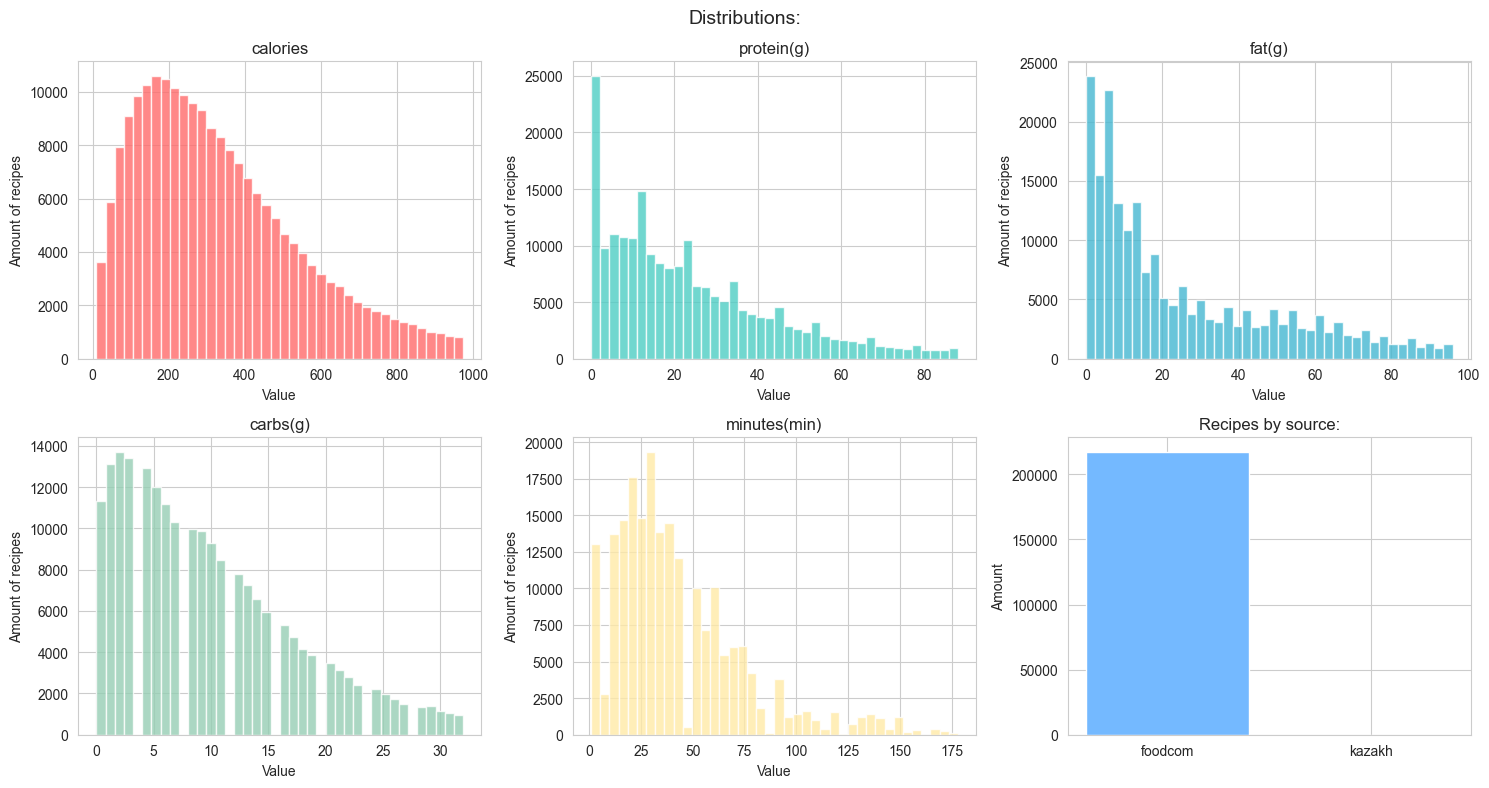

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distributions:', fontsize=14)

cols = ['calories', 'protein', 'fat', 'carbs', 'minutes']
titles = ['calories', 'protein(g)', 'fat(g)', 'carbs(g)', 'minutes(min)']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for i, (col, title, color) in enumerate(zip(cols, titles, colors)):
    ax = axes[i // 3][i % 3]
    data = recipies[col][recipies[col] < recipies[col].quantile(0.95)]
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Amount of recipes')

ax = axes[1][2]
source_counts = recipies['source'].value_counts()
ax.bar(source_counts.index, source_counts.values, color=['#74B9FF', '#FD79A8'])
ax.set_title('Recipes by source:')
ax.set_ylabel('Amount')

plt.tight_layout()
plt.show()

## 10.Saving final dataset

In [58]:
recipies[['calories','protein','fat','carbs']] = recipies[['calories','protein','fat','carbs']].round(2)
recipies.to_csv('../data/clean/recipes_clean.csv', index=False)

print('File saved: data/clean/recipes_clean.csv')
print('Total recipies:', len(recipies))
print()
print('Example of final result:')
print(recipies[['name','minutes','calories','protein','fat','carbs','source']].head(10))

File saved: data/clean/recipes_clean.csv
Total recipies: 217653

Example of final result:
                                         name  minutes  calories  protein  \
0  arriba   baked winter squash mexican style     55.0      51.5      0.0   
1            a bit different  breakfast pizza     30.0     173.4     18.0   
2                   all in the kitchen  chili    130.0     269.8     22.0   
3                          alouette  potatoes     45.0     368.1     17.0   
4          amish  tomato ketchup  for canning    190.0     352.9      1.0   
5                       aww  marinated olives     15.0     380.7     53.0   
6              backyard style  barbecued ribs    120.0    1109.5     83.0   
7                 berry  good sandwich spread      5.0      79.2      3.0   
8                              chile rellenos     45.0      94.0     10.0   
9                              chinese  candy     15.0     232.7     21.0   

    fat  carbs   source  
0   2.0    4.0  foodcom  
1  22.0   